# 멀티헤드 분류 모델 비교 + 최고 모델 튜닝

**모델 3종**
- EfficientNetV2-S
- ConvNeXt-Tiny
- ResNet50

**평가 방식**
- 5-fold Stratified Cross Validation
- emotion F1 / visual F1 / space F1 / exact match / confusion matrix

**튜닝**
- 최고 성능 모델을 label smoothing / mixup / layer-wise LR decay로 재학습

## 0. 설치 (최초 1회)

In [27]:
!pip install torch torchvision scikit-learn pandas matplotlib seaborn tqdm

## 1. 설정

In [28]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.models as tvm
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

CSV_PATH   = "/home/piai/b2/PBA_AI_Project/modeling/image/space_mood_tag_captioned.csv"
IMAGE_ROOT = "/home/piai/다운로드/mood_tag/data"
SAVE_DIR   = "/home/piai/b2/PBA_AI_Project/modeling/image/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE     = 224
BATCH_SIZE   = 16
EPOCHS       = 20
LR           = 3e-4
WEIGHT_DECAY = 1e-4
N_FOLDS      = 5
NUM_WORKERS  = 2
EMOTION_W, VISUAL_W, SPACE_W = 1.0, 1.0, 1.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

Device: cuda
GPU: NVIDIA RTX A5000


## 2. 데이터 로드 & 라벨 인코딩

In [29]:
df = pd.read_csv(CSV_PATH)
for col in ["emotion", "visual", "space"]:
    df[col] = df[col].str.strip().str.lower()

def find_image_path(row_id):
    for ext in ["jpg", "jpeg", "png", "webp"]:
        p = os.path.join(IMAGE_ROOT, f"image_{int(row_id):03d}.{ext}")
        if os.path.exists(p):
            return p
    return None

df["full_path"] = df["id"].apply(find_image_path)
missing = df["full_path"].isna().sum()
print(f"이미지 없는 행: {missing}개 / 전체 {len(df)}개")
df = df.dropna(subset=["full_path"]).reset_index(drop=True)
print(f"학습에 사용할 행: {len(df)}개")

emotion_le = LabelEncoder()
visual_le  = LabelEncoder()
space_le   = LabelEncoder()
df["emotion_idx"] = emotion_le.fit_transform(df["emotion"])
df["visual_idx"]  = visual_le.fit_transform(df["visual"])
df["space_idx"]   = space_le.fit_transform(df["space"])

NUM_EMOTION = df["emotion_idx"].nunique()
NUM_VISUAL  = df["visual_idx"].nunique()
NUM_SPACE   = df["space_idx"].nunique()
print(f"emotion ({NUM_EMOTION}): {list(emotion_le.classes_)}")
print(f"visual  ({NUM_VISUAL}):  {list(visual_le.classes_)}")
print(f"space   ({NUM_SPACE}):   {list(space_le.classes_)}")
display(df.head())

이미지 없는 행: 0개 / 전체 294개
학습에 사용할 행: 294개
emotion (3): ['chic', 'cozy', 'lively']
visual  (4):  ['bright', 'cool', 'dark', 'warm']
space   (3):   ['compact', 'private', 'spacious']


,id,emotion,visual,space,tags,caption,full_path,emotion_idx,visual_idx,space_idx
0,0,cozy,warm,private,"cozy, warm, private","cozy atmosphere, warm golden lighting, exclusi...",/home/piai/다운로드/mood_tag/data/image_000.jpg,1,3,1
1,1,chic,cool,compact,"chic, cool, compact","refined modern atmosphere, cool-toned blue lig...",/home/piai/다운로드/mood_tag/data/image_001.jpg,0,1,0
2,2,lively,cool,private,"lively, cool, private","vibrant party atmosphere, icy blue-white ambia...",/home/piai/다운로드/mood_tag/data/image_002.jpg,2,1,1
3,3,lively,warm,compact,"lively, warm, compact","lively and energetic vibe, soft warm-toned glo...",/home/piai/다운로드/mood_tag/data/image_003.jpg,2,3,0
4,4,cozy,warm,spacious,"cozy, warm, spacious","cozy atmosphere, warm golden lighting, spaciou...",/home/piai/다운로드/mood_tag/data/image_004.jpg,1,3,2


## 3. Dataset & Transform

In [30]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
valid_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class SpaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return {
            "image":   img,
            "emotion": torch.tensor(int(row["emotion_idx"]), dtype=torch.long),
            "visual":  torch.tensor(int(row["visual_idx"]),  dtype=torch.long),
            "space":   torch.tensor(int(row["space_idx"]),   dtype=torch.long),
        }

print("Dataset 클래스 정의 완료")

Dataset 클래스 정의 완료


## 4. 모델 정의 (3종 공통 멀티헤드 구조)

In [31]:
class MultiHeadClassifier(nn.Module):
    def __init__(self, backbone, backbone_out_dim, num_emotion, num_visual, num_space, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.neck = nn.Sequential(nn.Linear(backbone_out_dim, 256), nn.ReLU(), nn.Dropout(dropout))
        self.emotion_head = nn.Linear(256, num_emotion)
        self.visual_head  = nn.Linear(256, num_visual)
        self.space_head   = nn.Linear(256, num_space)

    def forward(self, x):
        f = self.backbone(x)
        if f.dim() > 2:          # ConvNeXt 등 classifier 제거 시 4D 출력 방어
            f = f.flatten(1)
        f = self.neck(f)
        return self.emotion_head(f), self.visual_head(f), self.space_head(f)

def build_efficientnet(n_emo, n_vis, n_spa):
    m = tvm.efficientnet_v2_s(weights=tvm.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    dim = m.classifier[1].in_features; m.classifier = nn.Identity()
    return MultiHeadClassifier(m, dim, n_emo, n_vis, n_spa)

def build_convnext(n_emo, n_vis, n_spa):
    m = tvm.convnext_tiny(weights=tvm.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    dim = m.classifier[2].in_features; m.classifier = nn.Identity()
    return MultiHeadClassifier(m, dim, n_emo, n_vis, n_spa)

def build_resnet(n_emo, n_vis, n_spa):
    m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
    dim = m.fc.in_features; m.fc = nn.Identity()
    return MultiHeadClassifier(m, dim, n_emo, n_vis, n_spa)

MODEL_BUILDERS = {
    "EfficientNetV2-S": build_efficientnet,
    "ConvNeXt-Tiny":    build_convnext,
    "ResNet50":         build_resnet,
}
print("모델 빌더 등록:", list(MODEL_BUILDERS.keys()))

모델 빌더 등록: ['EfficientNetV2-S', 'ConvNeXt-Tiny', 'ResNet50']


## 5. 학습 / 검증 함수

In [32]:
def make_weights(labels, n):
    c = np.maximum(np.bincount(labels, minlength=n).astype(float), 1)
    return torch.tensor(len(labels) / (n * c), dtype=torch.float32).to(DEVICE)

def exact_match(et, vt, st, ep, vp, sp):
    et, vt, st, ep, vp, sp = (np.array(x) for x in [et, vt, st, ep, vp, sp])
    return float(((et == ep) & (vt == vp) & (st == sp)).mean())

def train_epoch(model, loader, optimizer, criteria):
    model.train(); ce, cv, cs = criteria; total = 0
    for b in loader:
        img = b["image"].to(DEVICE); emo = b["emotion"].to(DEVICE)
        vis = b["visual"].to(DEVICE); spa = b["space"].to(DEVICE)
        optimizer.zero_grad()
        eo, vo, so = model(img)
        loss = EMOTION_W*ce(eo,emo) + VISUAL_W*cv(vo,vis) + SPACE_W*cs(so,spa)
        loss.backward(); optimizer.step(); total += loss.item()
    return total / len(loader)

@torch.no_grad()
def valid_epoch(model, loader, criteria):
    model.eval(); ce, cv, cs = criteria; total = 0
    et, ep, vt, vp, st, sp = [], [], [], [], [], []
    for b in loader:
        img = b["image"].to(DEVICE); emo = b["emotion"].to(DEVICE)
        vis = b["visual"].to(DEVICE); spa = b["space"].to(DEVICE)
        eo, vo, so = model(img)
        total += (EMOTION_W*ce(eo,emo)+VISUAL_W*cv(vo,vis)+SPACE_W*cs(so,spa)).item()
        et.extend(emo.cpu().numpy()); ep.extend(eo.argmax(1).cpu().numpy())
        vt.extend(vis.cpu().numpy()); vp.extend(vo.argmax(1).cpu().numpy())
        st.extend(spa.cpu().numpy()); sp.extend(so.argmax(1).cpu().numpy())
    return {
        "loss": total/len(loader),
        "emotion_f1":  f1_score(et, ep, average="macro", zero_division=0),
        "visual_f1":   f1_score(vt, vp, average="macro", zero_division=0),
        "space_f1":    f1_score(st, sp, average="macro", zero_division=0),
        "exact_match": exact_match(et, vt, st, ep, vp, sp),
        "emotion_true": et, "emotion_pred": ep,
        "visual_true":  vt, "visual_pred":  vp,
        "space_true":   st, "space_pred":   sp,
    }

print("학습/검증 함수 정의 완료")

학습/검증 함수 정의 완료


## 6. 5-Fold CV — 3종 모델 비교

In [33]:
import pickle

CKPT_DIR = os.path.join(SAVE_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

def run_kfold(model_name):
    build_fn  = MODEL_BUILDERS[model_name]
    skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    strat_key = (df["emotion_idx"].astype(str)+"_"+df["visual_idx"].astype(str)+"_"+df["space_idx"].astype(str)).values
    fold_results = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(df, strat_key)):
        print(f"  [{model_name}] Fold {fold+1}/{N_FOLDS}", end=" ")
        tr_df = df.iloc[tr_idx].reset_index(drop=True)
        vl_df = df.iloc[val_idx].reset_index(drop=True)
        criteria = (
            nn.CrossEntropyLoss(weight=make_weights(tr_df["emotion_idx"].values, NUM_EMOTION)),
            nn.CrossEntropyLoss(weight=make_weights(tr_df["visual_idx"].values,  NUM_VISUAL)),
            nn.CrossEntropyLoss(weight=make_weights(tr_df["space_idx"].values,   NUM_SPACE)),
        )
        tr_loader = DataLoader(SpaceDataset(tr_df, train_tf), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
        vl_loader = DataLoader(SpaceDataset(vl_df, valid_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        model     = build_fn(NUM_EMOTION, NUM_VISUAL, NUM_SPACE).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        best_score, best_metrics = -1.0, None
        for epoch in range(1, EPOCHS+1):
            train_epoch(model, tr_loader, optimizer, criteria)
            val = valid_epoch(model, vl_loader, criteria)
            scheduler.step()
            score = (val["emotion_f1"]+val["visual_f1"]+val["space_f1"])/3
            if score > best_score: best_score, best_metrics = score, val
        print(f"-> mean_f1={best_score:.4f}  exact={best_metrics['exact_match']:.4f}")
        fold_results.append(best_metrics)
    return {
        "model":          model_name,
        "emotion_f1":     np.mean([r["emotion_f1"]  for r in fold_results]),
        "visual_f1":      np.mean([r["visual_f1"]   for r in fold_results]),
        "space_f1":       np.mean([r["space_f1"]    for r in fold_results]),
        "exact_match":    np.mean([r["exact_match"] for r in fold_results]),
        "mean_f1":        np.mean([(r["emotion_f1"]+r["visual_f1"]+r["space_f1"])/3 for r in fold_results]),
        "emotion_f1_std": np.std([r["emotion_f1"] for r in fold_results]),
        "visual_f1_std":  np.std([r["visual_f1"]  for r in fold_results]),
        "space_f1_std":   np.std([r["space_f1"]   for r in fold_results]),
        "fold_results":   fold_results,
    }

# 이전 체크포인트 불러오기 (셀 재실행 시 기존 결과 유지)
all_results = []
for mn in MODEL_BUILDERS:
    ckpt = os.path.join(CKPT_DIR, f"{mn.replace(' ','_')}_result.pkl")
    if os.path.exists(ckpt):
        with open(ckpt, "rb") as f:
            r = pickle.load(f)
        all_results.append(r)
        print(f"[체크포인트 로드] {mn}: mean_f1={r['mean_f1']:.4f}")

print(f"\nrun_kfold 정의 완료 | 기존 결과 {len(all_results)}/3개 로드")

[체크포인트 로드] EfficientNetV2-S: mean_f1=0.5803

run_kfold 정의 완료 | 기존 결과 1/3개 로드


In [34]:
## EfficientNetV2-S
_MODEL = "EfficientNetV2-S"
_ckpt  = os.path.join(CKPT_DIR, f"{_MODEL.replace(' ','_')}_result.pkl")

if os.path.exists(_ckpt):
    with open(_ckpt, "rb") as f:
        _result = pickle.load(f)
    print(f"[스킵] {_MODEL} 체크포인트 로드 완료 | mean_f1={_result['mean_f1']:.4f}")
else:
    print(f"\n{'='*55}\n모델: {_MODEL}\n{'='*55}")
    _result = run_kfold(_MODEL)
    with open(_ckpt, "wb") as f:
        pickle.dump(_result, f)
    print(f"  저장: {_ckpt}")
    print(f"  평균 -> emotion_f1={_result['emotion_f1']:.4f}  visual_f1={_result['visual_f1']:.4f}"
          f"  space_f1={_result['space_f1']:.4f}  exact={_result['exact_match']:.4f}  mean_f1={_result['mean_f1']:.4f}")

all_results = [r for r in all_results if r["model"] != _MODEL]
all_results.append(_result)

[스킵] EfficientNetV2-S 체크포인트 로드 완료 | mean_f1=0.5803


In [35]:
## ConvNeXt-Tiny
_MODEL = "ConvNeXt-Tiny"
_ckpt  = os.path.join(CKPT_DIR, f"{_MODEL.replace(' ','_')}_result.pkl")

if os.path.exists(_ckpt):
    with open(_ckpt, "rb") as f:
        _result = pickle.load(f)
    print(f"[스킵] {_MODEL} 체크포인트 로드 완료 | mean_f1={_result['mean_f1']:.4f}")
else:
    print(f"\n{'='*55}\n모델: {_MODEL}\n{'='*55}")
    _result = run_kfold(_MODEL)
    with open(_ckpt, "wb") as f:
        pickle.dump(_result, f)
    print(f"  저장: {_ckpt}")
    print(f"  평균 -> emotion_f1={_result['emotion_f1']:.4f}  visual_f1={_result['visual_f1']:.4f}"
          f"  space_f1={_result['space_f1']:.4f}  exact={_result['exact_match']:.4f}  mean_f1={_result['mean_f1']:.4f}")

all_results = [r for r in all_results if r["model"] != _MODEL]
all_results.append(_result)


모델: ConvNeXt-Tiny
  [ConvNeXt-Tiny] Fold 1/5 

-> mean_f1=0.5783  exact=0.2542
  [ConvNeXt-Tiny] Fold 2/5 -> mean_f1=0.5340  exact=0.2373
  [ConvNeXt-Tiny] Fold 3/5 -> mean_f1=0.6311  exact=0.3051
  [ConvNeXt-Tiny] Fold 4/5 -> mean_f1=0.5803  exact=0.2203
  [ConvNeXt-Tiny] Fold 5/5 -> mean_f1=0.6349  exact=0.2759
  저장: /home/piai/b2/PBA_AI_Project/modeling/image/saved_models/checkpoints/ConvNeXt-Tiny_result.pkl
  평균 -> emotion_f1=0.6237  visual_f1=0.6024  space_f1=0.5491  exact=0.2586  mean_f1=0.5917


In [36]:
## ResNet50
_MODEL = "ResNet50"
_ckpt  = os.path.join(CKPT_DIR, f"{_MODEL.replace(' ','_')}_result.pkl")

if os.path.exists(_ckpt):
    with open(_ckpt, "rb") as f:
        _result = pickle.load(f)
    print(f"[스킵] {_MODEL} 체크포인트 로드 완료 | mean_f1={_result['mean_f1']:.4f}")
else:
    print(f"\n{'='*55}\n모델: {_MODEL}\n{'='*55}")
    _result = run_kfold(_MODEL)
    with open(_ckpt, "wb") as f:
        pickle.dump(_result, f)
    print(f"  저장: {_ckpt}")
    print(f"  평균 -> emotion_f1={_result['emotion_f1']:.4f}  visual_f1={_result['visual_f1']:.4f}"
          f"  space_f1={_result['space_f1']:.4f}  exact={_result['exact_match']:.4f}  mean_f1={_result['mean_f1']:.4f}")

all_results = [r for r in all_results if r["model"] != _MODEL]
all_results.append(_result)


모델: ResNet50
  [ResNet50] Fold 1/5 -> mean_f1=0.5808  exact=0.2542
  [ResNet50] Fold 2/5 -> mean_f1=0.5367  exact=0.2881
  [ResNet50] Fold 3/5 -> mean_f1=0.5412  exact=0.2034
  [ResNet50] Fold 4/5 -> mean_f1=0.5939  exact=0.1864
  [ResNet50] Fold 5/5 -> mean_f1=0.6380  exact=0.3448
  저장: /home/piai/b2/PBA_AI_Project/modeling/image/saved_models/checkpoints/ResNet50_result.pkl
  평균 -> emotion_f1=0.5832  visual_f1=0.6106  space_f1=0.5406  exact=0.2554  mean_f1=0.5781


## 7. 비교 결과표 & 차트

In [37]:
summary_cols = ["model","emotion_f1","visual_f1","space_f1","exact_match","mean_f1",
                "emotion_f1_std","visual_f1_std","space_f1_std"]
summary_df = pd.DataFrame([{c: r[c] for c in summary_cols} for r in all_results])
pd.set_option("display.float_format", "{:.4f}".format)
display(summary_df)
best_model_name = summary_df.loc[summary_df["mean_f1"].idxmax(), "model"]
print(f"\n★ 최고 성능 모델: {best_model_name}")
summary_df.to_csv(os.path.join(SAVE_DIR, "comparison_results.csv"), index=False)

,model,emotion_f1,visual_f1,space_f1,exact_match,mean_f1,emotion_f1_std,visual_f1_std,space_f1_std
0,EfficientNetV2-S,0.6056,0.5587,0.5764,0.2178,0.5803,0.0648,0.0666,0.0466
1,ConvNeXt-Tiny,0.6237,0.6024,0.5491,0.2586,0.5917,0.0597,0.0984,0.0355
2,ResNet50,0.5832,0.6106,0.5406,0.2554,0.5781,0.0316,0.0528,0.0567



★ 최고 성능 모델: ConvNeXt-Tiny


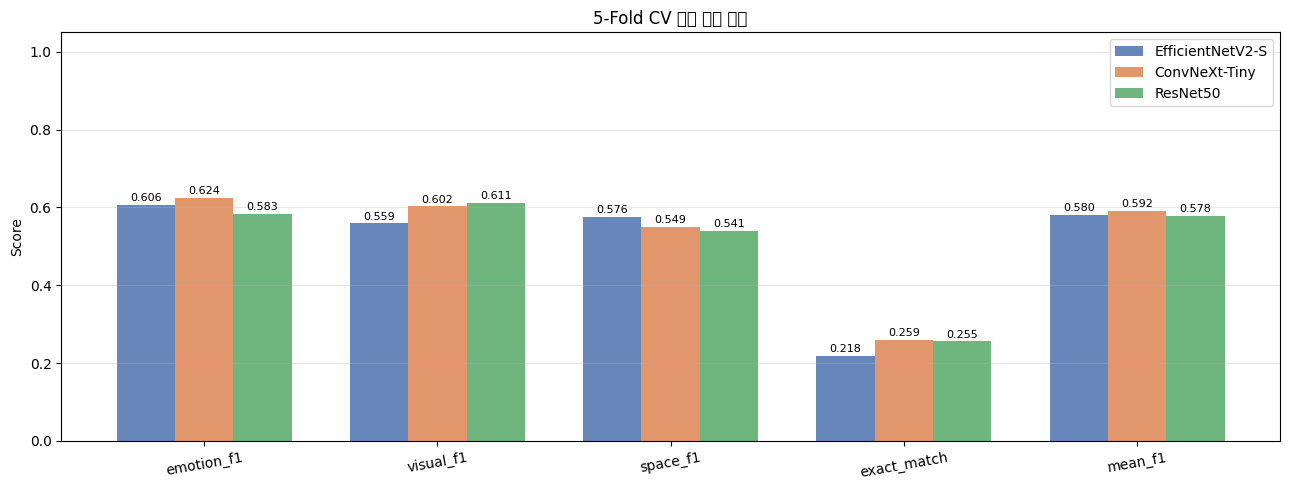

In [38]:
metrics = ["emotion_f1","visual_f1","space_f1","exact_match","mean_f1"]
x, w, colors = np.arange(len(metrics)), 0.25, ["#4C72B0","#DD8452","#55A868"]
fig, ax = plt.subplots(figsize=(13,5))
for i, (_, row) in enumerate(summary_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x+i*w, vals, w, label=row["model"], color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x+w); ax.set_xticklabels(metrics, rotation=10)
ax.set_ylim(0,1.05); ax.set_ylabel("Score"); ax.set_title("5-Fold CV 모델 성능 비교")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model_comparison.png"), dpi=150)
plt.show()

## 8. Confusion Matrix (최고 모델)

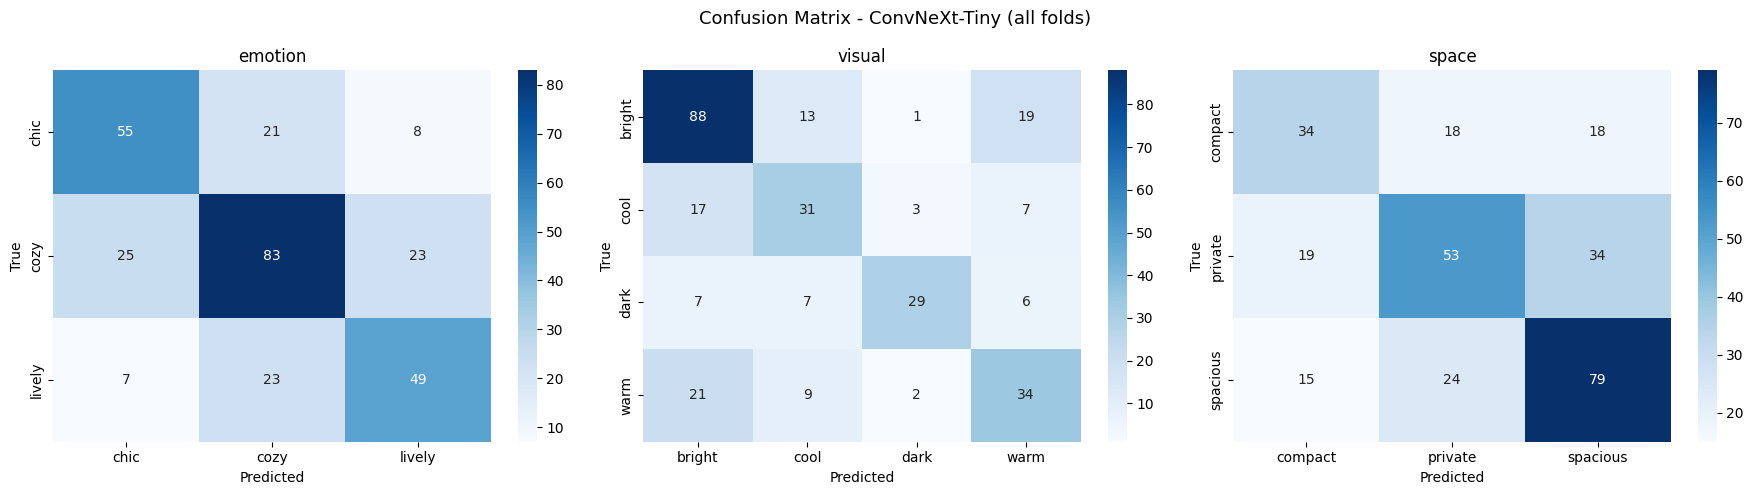


=== emotion ===
              precision    recall  f1-score   support

        chic       0.63      0.65      0.64        84
        cozy       0.65      0.63      0.64       131
      lively       0.61      0.62      0.62        79

    accuracy                           0.64       294
   macro avg       0.63      0.64      0.63       294
weighted avg       0.64      0.64      0.64       294


=== visual ===
              precision    recall  f1-score   support

      bright       0.66      0.73      0.69       121
        cool       0.52      0.53      0.53        58
        dark       0.83      0.59      0.69        49
        warm       0.52      0.52      0.52        66

    accuracy                           0.62       294
   macro avg       0.63      0.59      0.61       294
weighted avg       0.63      0.62      0.62       294


=== space ===
              precision    recall  f1-score   support

     compact       0.50      0.49      0.49        70
     private       0.56    

In [39]:
best_result = next(r for r in all_results if r["model"] == best_model_name)
folds = best_result["fold_results"]
emo_t = sum([r["emotion_true"] for r in folds], []); emo_p = sum([r["emotion_pred"] for r in folds], [])
vis_t = sum([r["visual_true"]  for r in folds], []); vis_p = sum([r["visual_pred"]  for r in folds], [])
spa_t = sum([r["space_true"]   for r in folds], []); spa_p = sum([r["space_pred"]   for r in folds], [])

fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle(f"Confusion Matrix - {best_model_name} (all folds)", fontsize=13)
for ax, (name, t, p, classes) in zip(axes, [
    ("emotion", emo_t, emo_p, emotion_le.classes_),
    ("visual",  vis_t, vis_p, visual_le.classes_),
    ("space",   spa_t, spa_p, space_le.classes_),
]):
    sns.heatmap(confusion_matrix(t,p), annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"cm_{best_model_name.replace(' ','_')}.png"), dpi=150)
plt.show()

for name, t, p, classes in [
    ("emotion", emo_t, emo_p, emotion_le.classes_),
    ("visual",  vis_t, vis_p, visual_le.classes_),
    ("space",   spa_t, spa_p, space_le.classes_),
]:
    print(f"\n=== {name} ===")
    print(classification_report(t, p, target_names=classes, zero_division=0))

---
## 9. 최고 모델 튜닝

- **Label Smoothing** (0.1)
- **Mixup** (alpha=0.2)
- **Layer-wise LR Decay** — backbone 0.5x, neck/head 1x
- **Warmup + CosineAnnealing** — 30 epoch, 첫 3 epoch 워밍업

In [40]:
TUNE_EPOCHS=30; TUNE_LR=2e-4; TUNE_WEIGHT_DECAY=1e-4
LABEL_SMOOTHING=0.1; MIXUP_ALPHA=0.2; LR_DECAY_RATE=0.5; WARMUP_EPOCHS=3

def mixup_batch(imgs, le, lv, ls, alpha=0.2):
    if alpha <= 0: return imgs, le, lv, ls, None
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam*imgs+(1-lam)*imgs[idx], le, lv, ls, (le[idx], lv[idx], ls[idx], lam)

def mixup_loss(criterion, pred, ya, yb, lam):
    return lam*criterion(pred,ya) + (1-lam)*criterion(pred,yb)

def get_param_groups(model, base_lr, decay):
    return [
        {"params": list(model.backbone.parameters()), "lr": base_lr*decay},
        {"params": list(model.neck.parameters())+list(model.emotion_head.parameters())+
                   list(model.visual_head.parameters())+list(model.space_head.parameters()), "lr": base_lr},
    ]

def warmup_lambda(epoch):
    return (epoch+1)/WARMUP_EPOCHS if epoch < WARMUP_EPOCHS else 1.0

print("튜닝 설정 완료")

튜닝 설정 완료


In [41]:
def run_kfold_tuned(model_name):
    build_fn  = MODEL_BUILDERS[model_name]
    skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    strat_key = (df["emotion_idx"].astype(str)+"_"+df["visual_idx"].astype(str)+"_"+df["space_idx"].astype(str)).values
    fold_results = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(df, strat_key)):
        print(f"  [Tuned {model_name}] Fold {fold+1}/{N_FOLDS}", end=" ")
        tr_df = df.iloc[tr_idx].reset_index(drop=True)
        vl_df = df.iloc[val_idx].reset_index(drop=True)
        criteria = (
            nn.CrossEntropyLoss(weight=make_weights(tr_df["emotion_idx"].values,NUM_EMOTION),label_smoothing=LABEL_SMOOTHING),
            nn.CrossEntropyLoss(weight=make_weights(tr_df["visual_idx"].values, NUM_VISUAL), label_smoothing=LABEL_SMOOTHING),
            nn.CrossEntropyLoss(weight=make_weights(tr_df["space_idx"].values,  NUM_SPACE),  label_smoothing=LABEL_SMOOTHING),
        )
        tr_loader = DataLoader(SpaceDataset(tr_df,train_tf), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
        vl_loader = DataLoader(SpaceDataset(vl_df,valid_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        model        = build_fn(NUM_EMOTION,NUM_VISUAL,NUM_SPACE).to(DEVICE)
        optimizer    = torch.optim.AdamW(get_param_groups(model,TUNE_LR,LR_DECAY_RATE), weight_decay=TUNE_WEIGHT_DECAY)
        warmup_sched = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lambda)
        cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TUNE_EPOCHS-WARMUP_EPOCHS)
        best_score, best_metrics = -1.0, None
        for epoch in range(1, TUNE_EPOCHS+1):
            model.train(); ce,cv,cs = criteria
            for b in tr_loader:
                img=b["image"].to(DEVICE); emo=b["emotion"].to(DEVICE)
                vis=b["visual"].to(DEVICE); spa=b["space"].to(DEVICE)
                img,emo,vis,spa,mix = mixup_batch(img,emo,vis,spa,MIXUP_ALPHA)
                optimizer.zero_grad(); eo,vo,so = model(img)
                if mix is not None:
                    eb,vb,sb,lam = mix
                    loss = EMOTION_W*mixup_loss(ce,eo,emo,eb,lam)+VISUAL_W*mixup_loss(cv,vo,vis,vb,lam)+SPACE_W*mixup_loss(cs,so,spa,sb,lam)
                else:
                    loss = EMOTION_W*ce(eo,emo)+VISUAL_W*cv(vo,vis)+SPACE_W*cs(so,spa)
                loss.backward(); optimizer.step()
            if epoch <= WARMUP_EPOCHS: warmup_sched.step()
            else: cosine_sched.step()
            val = valid_epoch(model, vl_loader, criteria)
            score = (val["emotion_f1"]+val["visual_f1"]+val["space_f1"])/3
            if score > best_score: best_score,best_metrics = score,val
        print(f"-> mean_f1={best_score:.4f}  exact={best_metrics['exact_match']:.4f}")
        fold_results.append(best_metrics)
    return {
        "model":          f"{model_name} (Tuned)",
        "emotion_f1":     np.mean([r["emotion_f1"]  for r in fold_results]),
        "visual_f1":      np.mean([r["visual_f1"]   for r in fold_results]),
        "space_f1":       np.mean([r["space_f1"]    for r in fold_results]),
        "exact_match":    np.mean([r["exact_match"] for r in fold_results]),
        "mean_f1":        np.mean([(r["emotion_f1"]+r["visual_f1"]+r["space_f1"])/3 for r in fold_results]),
        "emotion_f1_std": np.std([r["emotion_f1"] for r in fold_results]),
        "visual_f1_std":  np.std([r["visual_f1"]  for r in fold_results]),
        "space_f1_std":   np.std([r["space_f1"]   for r in fold_results]),
        "fold_results":   fold_results,
    }

print(f"\n{'='*55}\n최고 모델 튜닝: {best_model_name}\n{'='*55}")
tuned_result = run_kfold_tuned(best_model_name)
print(f"\n튜닝 전 mean_f1: {best_result['mean_f1']:.4f}")
print(f"튜닝 후 mean_f1: {tuned_result['mean_f1']:.4f}")
print(f"향상:           +{tuned_result['mean_f1']-best_result['mean_f1']:.4f}")


최고 모델 튜닝: ConvNeXt-Tiny
  [Tuned ConvNeXt-Tiny] Fold 1/5 -> mean_f1=0.6148  exact=0.2203
  [Tuned ConvNeXt-Tiny] Fold 2/5 -> mean_f1=0.5461  exact=0.2373
  [Tuned ConvNeXt-Tiny] Fold 3/5 -> mean_f1=0.6254  exact=0.2712
  [Tuned ConvNeXt-Tiny] Fold 4/5 -> mean_f1=0.5973  exact=0.2373
  [Tuned ConvNeXt-Tiny] Fold 5/5 -> mean_f1=0.6020  exact=0.2759

튜닝 전 mean_f1: 0.5917
튜닝 후 mean_f1: 0.5971
향상:           +0.0054


## 10. 튜닝 전/후 비교

,model,emotion_f1,visual_f1,space_f1,exact_match,mean_f1,emotion_f1_std,visual_f1_std,space_f1_std
0,ConvNeXt-Tiny,0.6237,0.6024,0.5491,0.2586,0.5917,0.0597,0.0984,0.0355
1,ConvNeXt-Tiny (Tuned),0.6138,0.6174,0.5600,0.2484,0.5971,0.0426,0.0488,0.0404


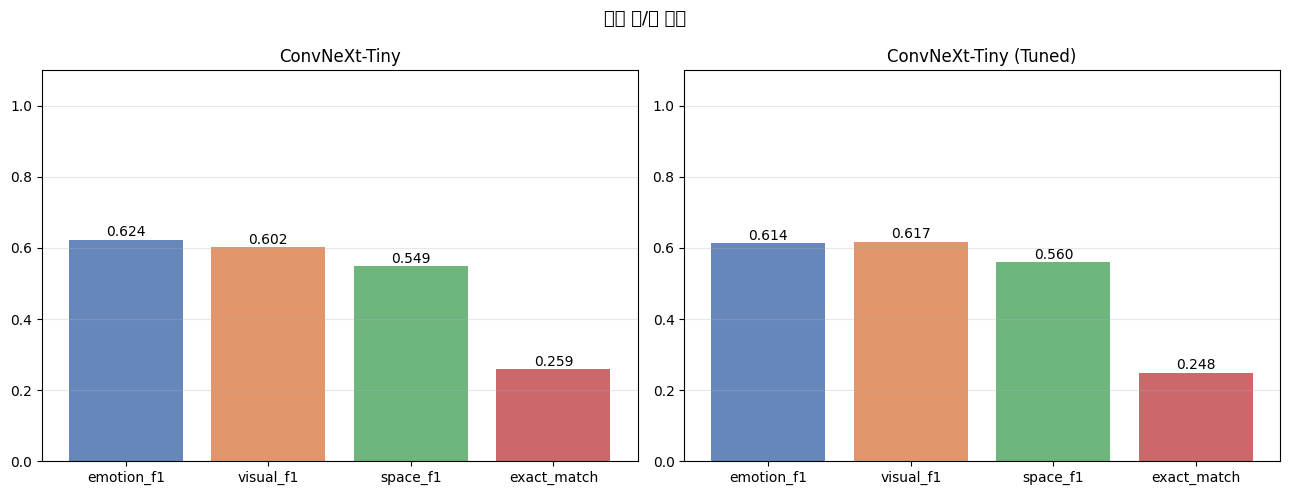

In [42]:
compare_df = pd.DataFrame([{c:best_result[c] for c in summary_cols},{c:tuned_result[c] for c in summary_cols}])
display(compare_df)
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, label, row in zip(axes,[best_model_name,f"{best_model_name} (Tuned)"],[best_result,tuned_result]):
    vals = [row["emotion_f1"],row["visual_f1"],row["space_f1"],row["exact_match"]]
    ax.bar(["emotion_f1","visual_f1","space_f1","exact_match"],vals,
           color=["#4C72B0","#DD8452","#55A868","#C44E52"],alpha=0.85)
    for i,v in enumerate(vals): ax.text(i,v+0.01,f"{v:.3f}",ha="center",fontsize=10)
    ax.set_ylim(0,1.1); ax.set_title(label); ax.grid(axis="y",alpha=0.3)
plt.suptitle("튜닝 전/후 비교",fontsize=13); plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"tuning_comparison.png"),dpi=150)
plt.show()

## 11. 최종 모델 전체 데이터로 재학습 & 저장

In [43]:
print(f"전체 {len(df)}장으로 최종 모델 학습: {best_model_name}")
criteria_final = (
    nn.CrossEntropyLoss(weight=make_weights(df["emotion_idx"].values,NUM_EMOTION),label_smoothing=LABEL_SMOOTHING),
    nn.CrossEntropyLoss(weight=make_weights(df["visual_idx"].values, NUM_VISUAL), label_smoothing=LABEL_SMOOTHING),
    nn.CrossEntropyLoss(weight=make_weights(df["space_idx"].values,  NUM_SPACE),  label_smoothing=LABEL_SMOOTHING),
)
full_loader  = DataLoader(SpaceDataset(df,train_tf),batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True)
final_model  = MODEL_BUILDERS[best_model_name](NUM_EMOTION,NUM_VISUAL,NUM_SPACE).to(DEVICE)
optimizer    = torch.optim.AdamW(get_param_groups(final_model,TUNE_LR,LR_DECAY_RATE),weight_decay=TUNE_WEIGHT_DECAY)
warmup_sched = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lambda)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=TUNE_EPOCHS-WARMUP_EPOCHS)
for epoch in tqdm(range(1,TUNE_EPOCHS+1),desc="Final Training"):
    train_epoch(final_model,full_loader,optimizer,criteria_final)
    if epoch <= WARMUP_EPOCHS: warmup_sched.step()
    else: cosine_sched.step()
save_path = os.path.join(SAVE_DIR,f"final_{best_model_name.replace(' ','_')}_tuned.pt")
torch.save({
    "model_state_dict": final_model.state_dict(),
    "model_name":       best_model_name,
    "emotion_classes":  list(emotion_le.classes_),
    "visual_classes":   list(visual_le.classes_),
    "space_classes":    list(space_le.classes_),
    "config": {"img_size":IMG_SIZE,"num_emotion":NUM_EMOTION,"num_visual":NUM_VISUAL,"num_space":NUM_SPACE},
}, save_path)
print(f"\n최종 모델 저장 완료: {save_path}")

전체 294장으로 최종 모델 학습: ConvNeXt-Tiny


Final Training: 100%|██████████| 30/30 [01:20<00:00,  2.68s/it]


최종 모델 저장 완료: /home/piai/b2/PBA_AI_Project/modeling/image/saved_models/final_ConvNeXt-Tiny_tuned.pt
